# Exploratory Data Analysis on US Olympic Weightlifting Data
By Owen Davis

## Introduction

This data consists of all competition entries into USAW sanctioned competitons, including meet name, date, athlete name, and related snatch and clean&jerk information. This EDA notebook dives heavily into feature engineering, modeling, and segmented analysis. 
For more information on how this notebook is organized, check the README file.

## Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load in data
df = pd.read_csv("../data/meet_results_CLEANED.csv")

In [3]:
df.head(3)

,Meet,Date,Weight Category,Name,Bodyweight,Sn#1,Sn#2,Sn#3,CJ#1,CJ#2,CJ#3,Best Sn,Best CJ,Total,WC_AgeGroup,WC_Gender,WC_BW
0,2025 Junior Pan American Games,8/21/2025,Junior Men's 88kg,Ryan McDonald,83.65,142,146,-149,177,182,-190,146,182,328,Junior 88kg,Men,NaN
1,2025 Junior Pan American Games,8/22/2025,Junior Women's 77kg,Ella Nicholson,75.00,105,110,114,126,131,-136,114,131,245,Junior 77kg,Women,NaN
2,2025 Junior Pan American Games,8/22/2025,Junior Women's 69kg,Nicole Caamano,68.50,92,-94,-95,110,-114,-115,92,110,202,Junior 69kg,Women,NaN


## Clean Dataset

In [4]:
# Clean dataset slightly more
# remove WC_BW, rename columns
df_cleaned = df.drop(columns="WC_BW")
df_cleaned = df_cleaned.rename(columns={"WC_Gender": "Gender", "WC_AgeGroup":"Age Group"})

# set date to date
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce')

# remove duplicates
df_cleaned = df_cleaned.drop_duplicates()

# remove crazy outliers
df_cleaned = df_cleaned[df_cleaned["Bodyweight"] <= 250]
df_cleaned = df_cleaned[df_cleaned["Bodyweight"] > 0]
df_cleaned = df_cleaned[df_cleaned["Total"] <= 400]
df_cleaned = df_cleaned[df_cleaned["Total"] > 0]

# convert all misses (negative or 0) to NaN
misses_to_nan_cols = ["Sn#1","Sn#2","Sn#3","CJ#1","CJ#2","CJ#3"]
for col in misses_to_nan_cols:
    df_cleaned[f"{col}_missed"] = df_cleaned[col] <= 0
df_cleaned[misses_to_nan_cols] = df_cleaned[misses_to_nan_cols].apply(lambda x: x.where(x > 0, np.nan))

# Find remaining outliers to make graph below cleaner
# Top BW outliers
df_cleaned[
    (df_cleaned["Total"].between(150, 250)) &
    (df_cleaned["Bodyweight"].between(200, 250))
]
# Only Brad Alexander should be adjusted, bodyweight actually around 88.5-97 (meets before/after), take average, 92.75
df_cleaned.loc[152811, "Bodyweight"] = 92.75

# very low bodyweight, high total outliers removal
df_cleaned = df_cleaned[
    df_cleaned["Bodyweight"].between(0, 200) & 
    (df_cleaned["Total"] <= 5.5 * df_cleaned["Bodyweight"])
]

# Low BW, 400kg total
df_cleaned[
    (df_cleaned["Total"].between(390, 400)) &
    (df_cleaned["Bodyweight"].between(60, 110))
]
# remove those in this category
df_cleaned = df_cleaned.drop(index=[66308, 66310, 66311, 66312, 66314, 120976, 120977])

## Feature Engineering

In [5]:
# Sort by athlete and date first
df_cleaned = df_cleaned.sort_values(['Name', 'Date']).reset_index(drop=True)

# Calculate expanding (cumulative) miss rates - excludes current row
miss_cols = ['Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed', 
             'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed']

for col in miss_cols:
    # Shift(1) moves everything down by 1, so current row uses only previous data
    # expanding() calculates cumulative mean up to that point
    df_cleaned[f'athlete_avg_{col}'] = (
        df_cleaned.groupby('Name')[col]
        .apply(lambda x: x.shift(1).expanding().mean())
        .reset_index(level=0, drop=True)
    )

In [6]:
# Best snatch/cj/total before current comp
df_cleaned['best_snatch_to_date'] = (
    df_cleaned.groupby('Name')['Best Sn']
    .apply(lambda x: x.shift(1).expanding().max())
    .reset_index(level=0, drop=True)
)

df_cleaned['best_cj_to_date'] = (
    df_cleaned.groupby('Name')['Best CJ']
    .apply(lambda x: x.shift(1).expanding().max())
    .reset_index(level=0, drop=True)
)

df_cleaned['best_total_to_date'] = (
    df_cleaned.groupby('Name')['Total']
    .apply(lambda x: x.shift(1).expanding().max())
    .reset_index(level=0, drop=True)
)

In [7]:
# Number of competitions before this one
df_cleaned['Num Competitions'] = df_cleaned.groupby('Name').cumcount()

# Time since last competition (in days)
df_cleaned['Days Since Last Comp'] = (
    df_cleaned.groupby('Name')['Date']
    .diff()
    .dt.days
)

# Last competition total
df_cleaned['Last Comp Total'] = (
    df_cleaned.groupby('Name')['Total']
    .shift(1)
)

# Time since best total (in days)
# First, find the date when athlete achieved their best total to date
df_cleaned['Date of Best Total'] = (
    df_cleaned.groupby('Name')
    .apply(lambda x: x['Date'].shift(1).where(
        x['Total'].shift(1) == x['Total'].shift(1).expanding().max()
    ).ffill())
    .reset_index(level=0, drop=True)
)

df_cleaned['Days Since Best Total'] = (
    (df_cleaned['Date'] - df_cleaned['Date of Best Total']).dt.days
)

C:\Users\odavi\AppData\Local\Temp\ipykernel_13608\738075146.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['Date'].shift(1).where(


In [8]:
df_cleaned['Gender Binary'] = df_cleaned['Gender'].map({
    'Men': 0,
    'Women': 1
})

In [9]:
# Helper function for safe polyfit
def safe_polyfit(y):
    try:
        if len(y) < 2:
            return 0
        # Check if all values are the same (no variance)
        if y.nunique() == 1:
            return 0
        return np.polyfit(range(len(y)), y, 1)[0]
    except (np.linalg.LinAlgError, ValueError):
        return 0

# Recent performance trend (last 3 comps)
df_cleaned['total_trend_last_3'] = (
    df_cleaned.groupby('Name')['Total']
    .apply(lambda x: x.shift(1).rolling(3, min_periods=2)
           .apply(safe_polyfit))
    .reset_index(level=0, drop=True)
)

# Acceleration (is improvement speeding up or slowing down?)
df_cleaned['total_acceleration'] = (
    df_cleaned.groupby('Name')['total_trend_last_3']
    .diff()
)

# Consecutive improvements
df_cleaned['improvement_streak'] = (
    df_cleaned.groupby('Name')['Total']
    .apply(lambda x: (x.shift(1) > x.shift(2)).astype(int).rolling(3).sum())
    .reset_index(level=0, drop=True)
)

# Ratio (typically 0.78-0.82 for balanced lifters)
df_cleaned['sn_to_cj_ratio'] = (
    df_cleaned.groupby('Name')['Best Sn'].shift(1) / 
    df_cleaned.groupby('Name')['Best CJ'].shift(1)
)

# Which lift is improving faster?
df_cleaned['sn_improvement_last_3'] = (
    df_cleaned.groupby('Name')['Best Sn']
    .apply(lambda x: x.shift(1).rolling(3, min_periods=2)
           .apply(safe_polyfit))
    .reset_index(level=0, drop=True)
)

df_cleaned['cj_improvement_last_3'] = (
    df_cleaned.groupby('Name')['Best CJ']
    .apply(lambda x: x.shift(1).rolling(3, min_periods=2)
           .apply(safe_polyfit))
    .reset_index(level=0, drop=True)
)

# Competition Frequency - simpler and more reliable approach
def count_comps_last_180_days(group):
    result = []
    for i, current_date in enumerate(group['Date']):
        if i == 0:
            result.append(0)  # First comp
        else:
            # Count comps in last 180 days (excluding current)
            past_dates = group['Date'].iloc[:i]
            count = ((current_date - past_dates).dt.days <= 180).sum()
            result.append(count)
    return pd.Series(result, index=group.index)

df_cleaned['comps_last_180_days'] = (
    df_cleaned.groupby('Name', group_keys=False)
    .apply(count_comps_last_180_days)
)

# Average days between competitions
df_cleaned['avg_days_between_comps'] = (
    df_cleaned.groupby('Name')['Days Since Last Comp']
    .apply(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

# Is this comp unusually soon/late?
df_cleaned['comp_timing_deviation'] = (
    df_cleaned['Days Since Last Comp'] - df_cleaned['avg_days_between_comps']
)

C:\Users\odavi\AppData\Local\Temp\ipykernel_13608\1480910576.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_comps_last_180_days)


## Cleaned and Feature Engineered Look at Data

In [10]:
df_cleaned.head(3)

,Meet,Date,Weight Category,Name,Bodyweight,Sn#1,Sn#2,Sn#3,CJ#1,CJ#2,...,Gender Binary,total_trend_last_3,total_acceleration,improvement_streak,sn_to_cj_ratio,sn_improvement_last_3,cj_improvement_last_3,comps_last_180_days,avg_days_between_comps,comp_timing_deviation
0,Unrivaled New Years Eve Throwdown,2016-12-31,Open Men's 94kg,A Rum Kim,91.4,86.0,NaN,92.0,109.0,113.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,Old Dominion Classic 2017,2017-01-22,Open Men's 94kg,A Rum Kim,85.1,92.0,96.0,NaN,118.0,NaN,...,0.0,NaN,NaN,NaN,0.814159,NaN,NaN,1,NaN,NaN
2,Unrivaled Spring Open 2017,2017-05-07,Open Men's 94kg,A Rum Kim,90.3,94.0,98.0,102.0,112.0,NaN,...,0.0,NaN,NaN,1.0,0.813559,NaN,NaN,2,22.0,83.0


## Visualizations

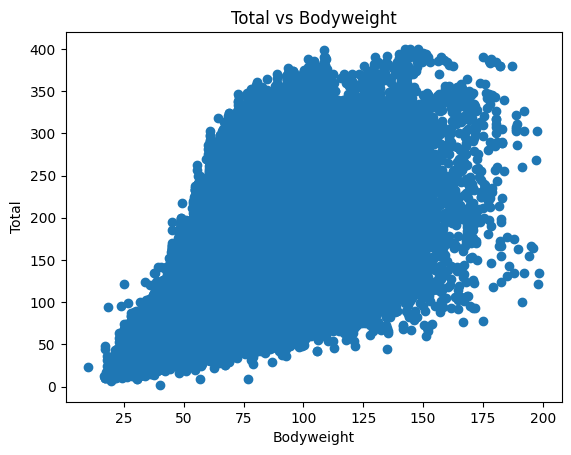

In [11]:
# Total vs Bodyweight
plt.scatter(df_cleaned["Bodyweight"], df_cleaned["Total"])
plt.xlabel("Bodyweight")
plt.ylabel("Total")
plt.title("Total vs Bodyweight")
plt.show()

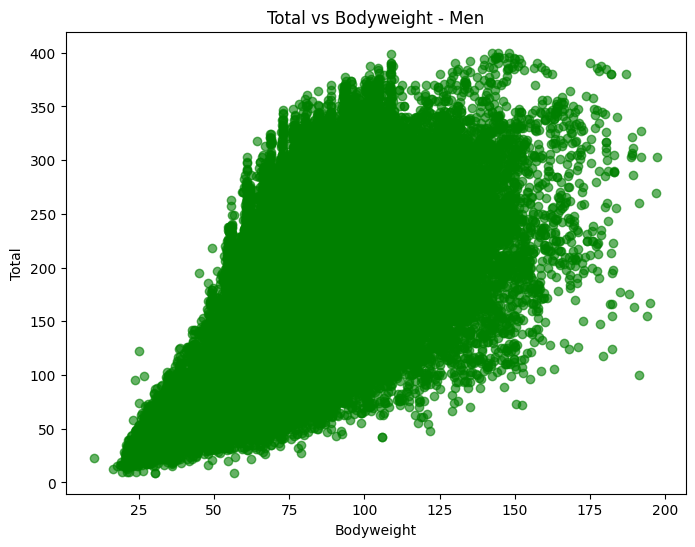

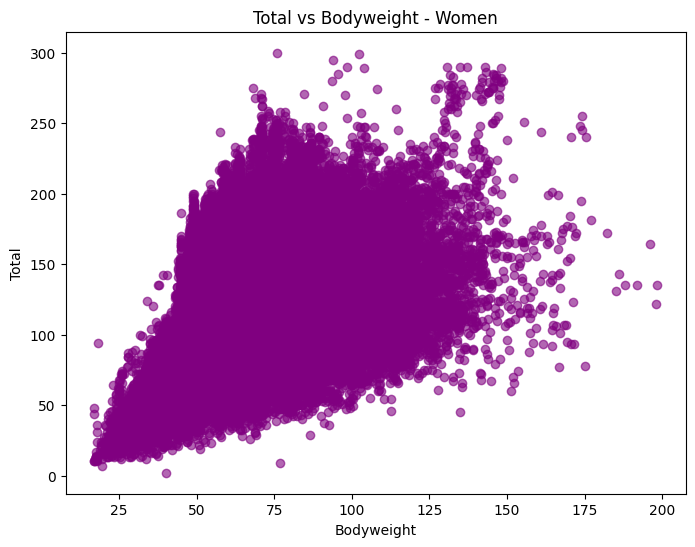

In [12]:
men = df_cleaned[df_cleaned["Gender"] == "Men"]
women = df_cleaned[df_cleaned["Gender"] == "Women"]

# Plot Men
plt.figure(figsize=(8,6))
plt.scatter(men["Bodyweight"], men["Total"], color="green", alpha=0.6)
plt.xlabel("Bodyweight")
plt.ylabel("Total")
plt.title("Total vs Bodyweight - Men")
plt.show()

# Plot Women
plt.figure(figsize=(8,6))
plt.scatter(women["Bodyweight"], women["Total"], color="purple", alpha=0.6)
plt.xlabel("Bodyweight")
plt.ylabel("Total")
plt.title("Total vs Bodyweight - Women")
plt.show()

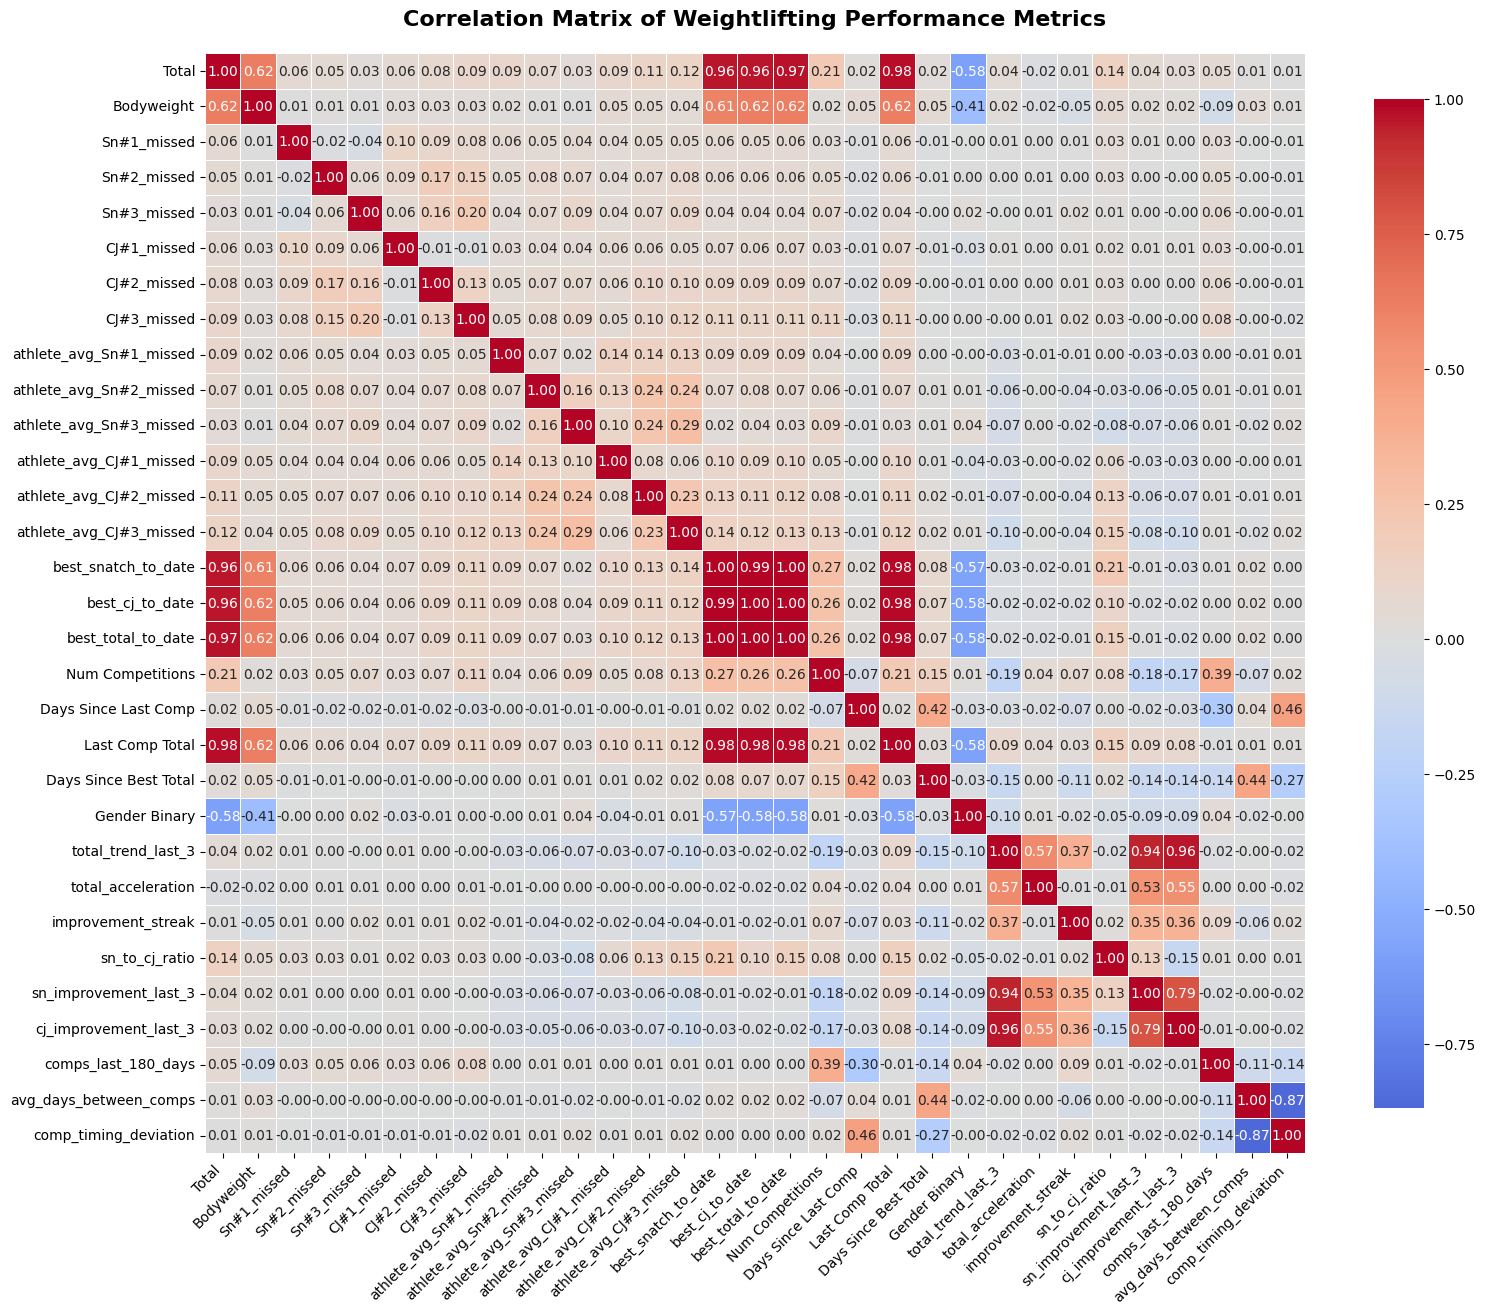

In [13]:
columns = ['Total', 'Bodyweight', 
           'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
           'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 
           'athlete_avg_Sn#1_missed', 'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
           'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed','athlete_avg_CJ#3_missed', 
           'best_snatch_to_date', 'best_cj_to_date',
           'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
           'Last Comp Total', 'Days Since Best Total',
           'Gender Binary', 'total_trend_last_3', 'total_acceleration',
           'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
           'cj_improvement_last_3', 'comps_last_180_days',
           'avg_days_between_comps', 'comp_timing_deviation']

# Calculate correlation matrix
corr_matrix = df_cleaned[columns].corr()

# Create figure
plt.figure(figsize=(16, 14))

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Weightlifting Performance Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2012.0


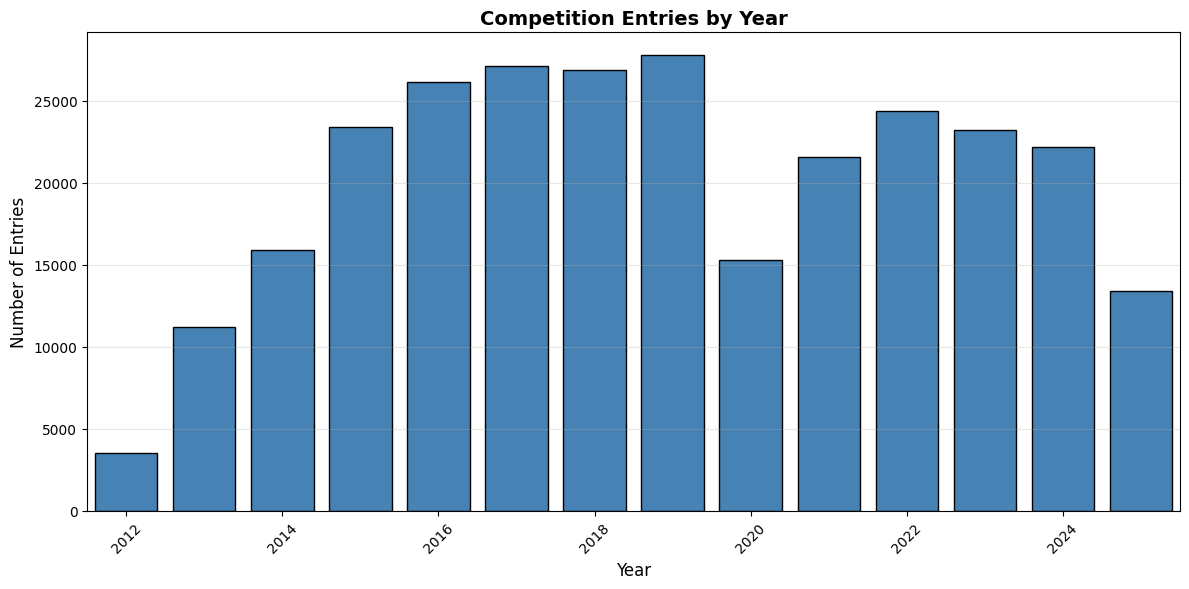

Total entries: 282,072
Year range: 2012.0 - 2025.0
Peak year: 2019.0 (27,770 entries)
Average entries per year: 20138


In [14]:
# number of entries by year
import matplotlib.pyplot as plt

# Extract year from Date column
year = df_cleaned['Date'].dt.year
year = year[year >= 2012]

# Count entries by year
entries_by_year = year.value_counts().sort_index()

# Filter out years with 0 entries (if any) and start from first year with data
first_year = entries_by_year.index.min()
last_year = entries_by_year.index.max()
print(first_year)
# Create the chart
plt.figure(figsize=(12, 6))
plt.bar(entries_by_year.index, entries_by_year.values, color='steelblue', edgecolor='black')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Entries', fontsize=12)
plt.title('Competition Entries by Year', fontsize=14, fontweight='bold')
plt.xlim(first_year - 0.5, last_year + 0.5)  # Add small buffer on edges
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total entries: {len(df_cleaned):,}")
print(f"Year range: {first_year} - {last_year}")
print(f"Peak year: {entries_by_year.idxmax()} ({entries_by_year.max():,} entries)")
print(f"Average entries per year: {entries_by_year.mean():.0f}")

In [15]:
# Calculate cumulative entries by year
entries_by_year_sorted = year.value_counts().sort_index()
cumulative_entries = entries_by_year_sorted.cumsum()
total_entries = len(year)

# Find 90% mark
ninetey_percent = total_entries * 0.90
cutoff_year = cumulative_entries[cumulative_entries <= ninetey_percent].index[-1]

print(f"Total entries (2000+): {total_entries:,}")
print(f"90% of entries: {ninetey_percent:,.0f}")
print(f"\n90/10 Split Cutoff Year: {cutoff_year}")
print(f"Entries up to {cutoff_year}: {cumulative_entries[cutoff_year]:,} ({cumulative_entries[cutoff_year]/total_entries*100:.1f}%)")
print(f"Entries after {cutoff_year}: {total_entries - cumulative_entries[cutoff_year]:,} ({(total_entries - cumulative_entries[cutoff_year])/total_entries*100:.1f}%)")

# Show breakdown around the cutoff
print(f"\nBreakdown around cutoff:")
cutoff_idx = entries_by_year_sorted.index.get_loc(cutoff_year)
for i in range(max(0, cutoff_idx-2), min(len(entries_by_year_sorted), cutoff_idx+3)):
    yr = entries_by_year_sorted.index[i]
    pct = cumulative_entries[yr] / total_entries * 100
    print(f"  {yr}: {cumulative_entries[yr]:,} entries ({pct:.1f}% cumulative)")

print(f"\nTrain/test split:")
print(f"train = df_cleaned[df_cleaned['Date'].dt.year <= {cutoff_year}]")
print(f"test = df_cleaned[df_cleaned['Date'].dt.year > {cutoff_year}]")

Total entries (2000+): 281,930
90% of entries: 253,737

90/10 Split Cutoff Year: 2023.0
Entries up to 2023.0: 246,394 (87.4%)
Entries after 2023.0: 35,536 (12.6%)

Breakdown around cutoff:
  2021.0: 198,797 entries (70.5% cumulative)
  2022.0: 223,189 entries (79.2% cumulative)
  2023.0: 246,394 entries (87.4% cumulative)
  2024.0: 268,539 entries (95.3% cumulative)
  2025.0: 281,930 entries (100.0% cumulative)

Train/test split:
train = df_cleaned[df_cleaned['Date'].dt.year <= 2023.0]
test = df_cleaned[df_cleaned['Date'].dt.year > 2023.0]


## Distributions

### Bodyweight

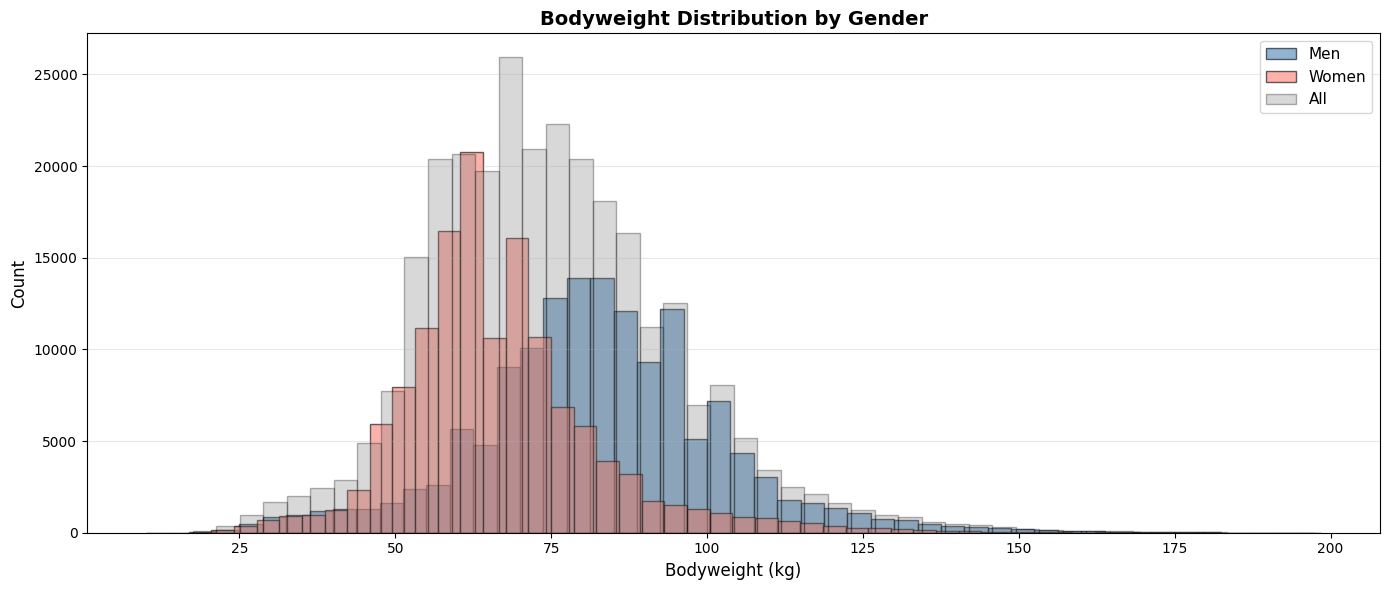

In [16]:
# Separate by gender
men_bodyweight = df_cleaned[df_cleaned['Gender'] == 'Men']['Bodyweight']
women_bodyweight = df_cleaned[df_cleaned['Gender'] == 'Women']['Bodyweight']
all_bodyweight = df_cleaned['Bodyweight']

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(men_bodyweight, bins=50, alpha=0.6, label='Men', color='steelblue', edgecolor='black')
plt.hist(women_bodyweight, bins=50, alpha=0.6, label='Women', color='salmon', edgecolor='black')
plt.hist(all_bodyweight, bins=50, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Bodyweight (kg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Bodyweight Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Total

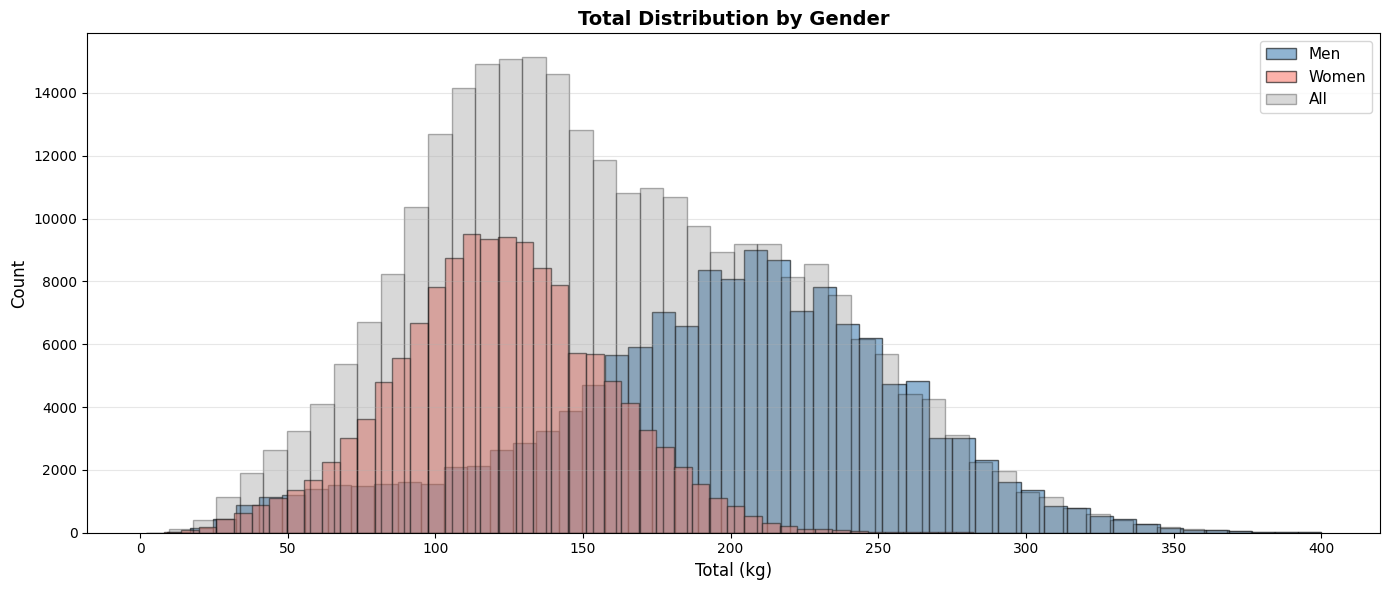

In [17]:
# Separate by gender
men_total = df_cleaned[df_cleaned['Gender'] == 'Men']['Total']
women_total = df_cleaned[df_cleaned['Gender'] == 'Women']['Total']
all_total = df_cleaned['Total']

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(men_total, bins=50, alpha=0.6, label='Men', color='steelblue', edgecolor='black')
plt.hist(women_total, bins=50, alpha=0.6, label='Women', color='salmon', edgecolor='black')
plt.hist(all_total, bins=50, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Total (kg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Total Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Number of Competitions

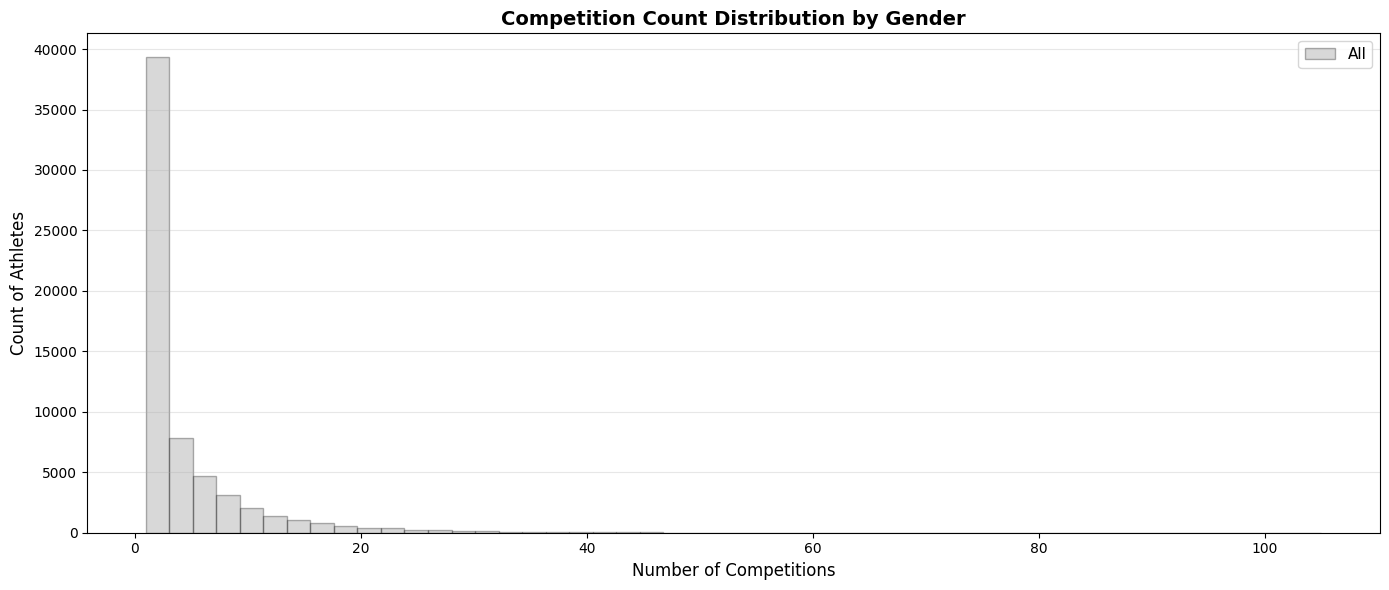

In [18]:
all_comp_counts = df_cleaned.groupby('Name').size()

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(all_comp_counts, bins=50, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Number of Competitions', fontsize=12)
plt.ylabel('Count of Athletes', fontsize=12)
plt.title('Competition Count Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [19]:
print("Bodyweight - Statistics:")
print(f"\nMen:")
print(f"  Mean: {men_bodyweight.mean():.1f} kg")
print(f"  Median: {men_bodyweight.median():.1f} kg")
print(f"  Range: {men_bodyweight.min():.1f} - {men_bodyweight.max():.1f} kg")

print(f"\nWomen:")
print(f"  Mean: {women_bodyweight.mean():.1f} kg")
print(f"  Median: {women_bodyweight.median():.1f} kg")
print(f"  Range: {women_bodyweight.min():.1f} - {women_bodyweight.max():.1f} kg")

print(f"\nAll:")
print(f"  Mean: {all_bodyweight.mean():.1f} kg")
print(f"  Median: {all_bodyweight.median():.1f} kg")
print(f"  Range: {all_bodyweight.min():.1f} - {all_bodyweight.max():.1f} kg")


print("----------------------------------------------------------------------")
print("Total - Statistics:")
print(f"\nMen:")
print(f"  Mean: {men_total.mean():.1f} kg")
print(f"  Median: {men_total.median():.1f} kg")
print(f"  Range: {men_total.min():.1f} - {men_total.max():.1f} kg")

print(f"\nWomen:")
print(f"  Mean: {women_total.mean():.1f} kg")
print(f"  Median: {women_total.median():.1f} kg")
print(f"  Range: {women_total.min():.1f} - {women_total.max():.1f} kg")

print(f"\nAll:")
print(f"  Mean: {all_total.mean():.1f} kg")
print(f"  Median: {all_total.median():.1f} kg")
print(f"  Range: {all_total.min():.1f} - {all_total.max():.1f} kg")

print("----------------------------------------------------------------------")
print("Number of Competitions - Statistics:")

print(f"\nAll:")
print(f"  Mean: {all_comp_counts.mean():.1f} Competitions")
print(f"  Median: {all_comp_counts.median():.1f} Competitions")
print(f"  Range: {all_comp_counts.min():.1f} - {all_comp_counts.max():.1f} Competitions")

print("----------------------------------------------------------------------")
print("Missed Lift Rates By Attempt - Statistics:")

cols = ["Sn#1", "Sn#2", "Sn#3", "CJ#1", "CJ#2", "CJ#3"]
nan_rates = df_cleaned[cols].isna().mean() * 100
nan_rates = nan_rates.round(1).astype(str) + '%'
print(nan_rates)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

sn_nan_rate = df_cleaned[sn_cols].isna().sum().sum() / df_cleaned[sn_cols].size * 100
cj_nan_rate = df_cleaned[cj_cols].isna().sum().sum() / df_cleaned[cj_cols].size * 100

sn_nan_rate = f"{sn_nan_rate:.1f}%"
cj_nan_rate = f"{cj_nan_rate:.1f}%"

print("Snatch Miss Rate:", sn_nan_rate)
print("Clean & Jerk Miss Rate:", cj_nan_rate)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall By Gender - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

for gender, df_gender in df_cleaned.groupby("Gender"):
    sn_miss_rate = (
        df_gender[sn_cols].isna().sum().sum() / df_gender[sn_cols].size * 100
    )
    cj_miss_rate = (
        df_gender[cj_cols].isna().sum().sum() / df_gender[cj_cols].size * 100
    )

    print(f"Gender: {gender}")
    print(f"  Snatch Miss Rate:        {sn_miss_rate:.1f}%")
    print(f"  Clean & Jerk Miss Rate:  {cj_miss_rate:.1f}%")
    print()


Bodyweight - Statistics:

Men:
  Mean: 82.9 kg
  Median: 82.8 kg
  Range: 10.0 - 197.5 kg

Women:
  Mean: 66.7 kg
  Median: 64.0 kg
  Range: 16.9 - 198.5 kg

All:
  Mean: 75.1 kg
  Median: 73.1 kg
  Range: 10.0 - 198.5 kg
----------------------------------------------------------------------
Total - Statistics:

Men:
  Mean: 195.3 kg
  Median: 201.0 kg
  Range: 9.0 - 400.0 kg

Women:
  Mean: 122.1 kg
  Median: 122.0 kg
  Range: 2.0 - 300.0 kg

All:
  Mean: 159.9 kg
  Median: 152.0 kg
  Range: 2.0 - 400.0 kg
----------------------------------------------------------------------
Number of Competitions - Statistics:

All:
  Mean: 4.5 Competitions
  Median: 2.0 Competitions
  Range: 1.0 - 105.0 Competitions
----------------------------------------------------------------------
Missed Lift Rates By Attempt - Statistics:
Sn#1    14.2%
Sn#2    25.3%
Sn#3    40.9%
CJ#1    10.3%
CJ#2    24.5%
CJ#3    43.8%
dtype: object
----------------------------------------------------------------------
Miss

In [20]:
print(df_cleaned.columns)

Index(['Meet', 'Date', 'Weight Category', 'Name', 'Bodyweight', 'Sn#1', 'Sn#2',
       'Sn#3', 'CJ#1', 'CJ#2', 'CJ#3', 'Best Sn', 'Best CJ', 'Total',
       'Age Group', 'Gender', 'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
       'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 'athlete_avg_Sn#1_missed',
       'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
       'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed',
       'athlete_avg_CJ#3_missed', 'best_snatch_to_date', 'best_cj_to_date',
       'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
       'Last Comp Total', 'Date of Best Total', 'Days Since Best Total',
       'Gender Binary', 'total_trend_last_3', 'total_acceleration',
       'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
       'cj_improvement_last_3', 'comps_last_180_days',
       'avg_days_between_comps', 'comp_timing_deviation'],
      dtype='object')


## Segmented Analysis Creation

### Explanation

Segmented Analysis will allow us to understand if ML models perform differently for specific performance categories. 
This section splits the data into the current (2026) weight categories for men and women, and determines three sections (Bottom 50th percentile, 50-85th, 85-100th) for future comparison against models.

### Split Data Up

Segment sizes:
Under 50th percentile: 135,710 entries (48.1%)
50th-85th percentile: 95,155 entries (33.7%)
85th-100th percentile: 40,697 entries (14.4%)


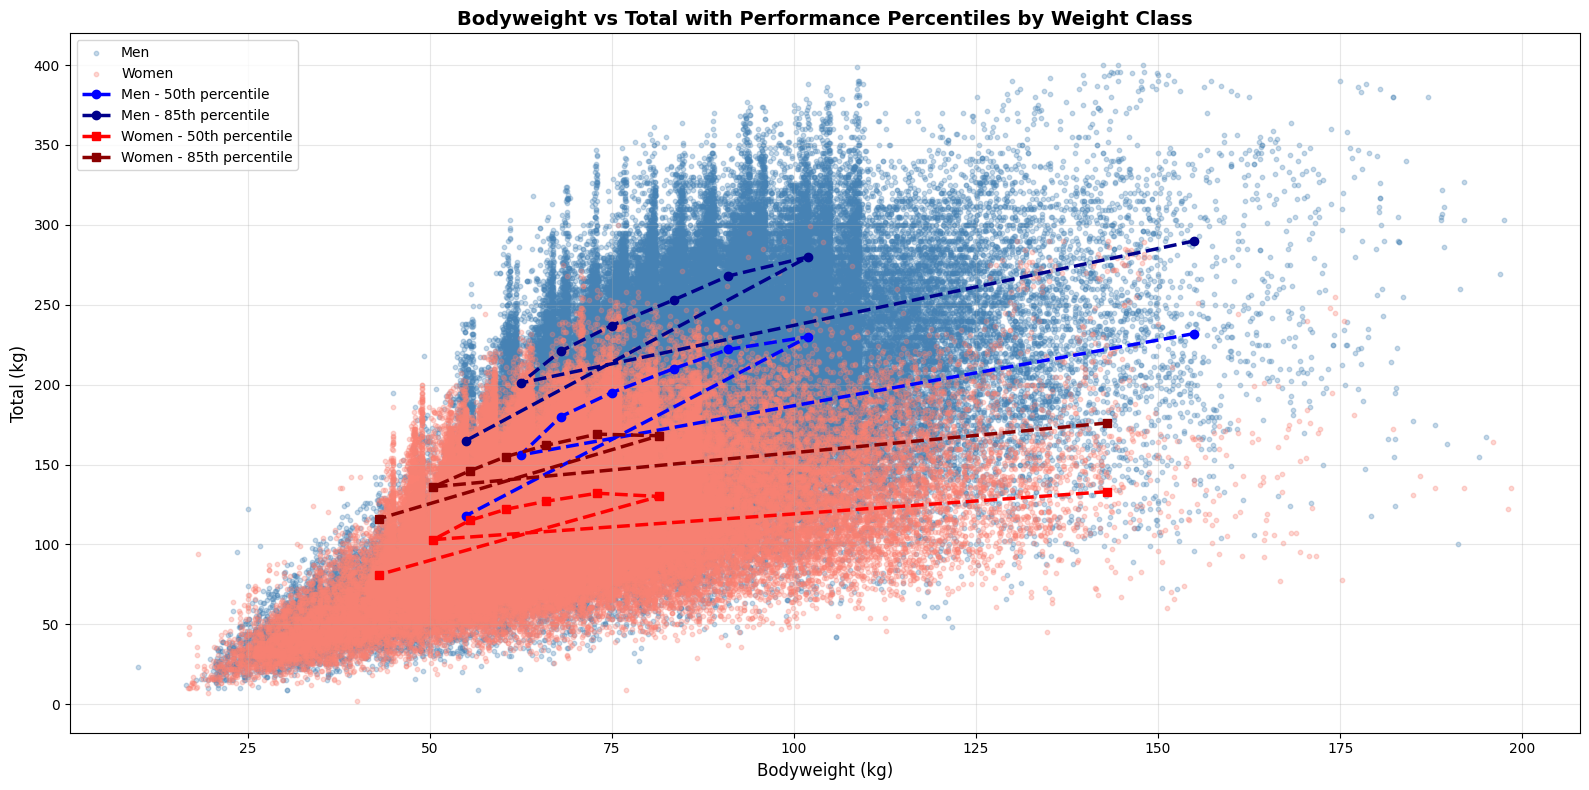


Performance statistics by weight class:

Men's Weight Classes:
  <60kg: n=6,701, 50th=118.0kg, 85th=165.0kg
  60-65kg: n=6,505, 50th=156.0kg, 85th=201.0kg
  65-71kg: n=13,219, 50th=180.0kg, 85th=221.0kg
  71-79kg: n=24,880, 50th=195.0kg, 85th=237.0kg
  79-88kg: n=32,911, 50th=210.0kg, 85th=253.0kg
  88-94kg: n=18,747, 50th=222.0kg, 85th=268.0kg
  94-110kg: n=25,236, 50th=230.0kg, 85th=280.0kg
  +110kg: n=10,056, 50th=232.0kg, 85th=290.0kg

Women's Weight Classes:
  <48kg: n=6,795, 50th=81.0kg, 85th=116.0kg
  48-53kg: n=10,175, 50th=103.0kg, 85th=136.0kg
  53-58kg: n=18,861, 50th=115.0kg, 85th=146.0kg
  58-63kg: n=23,480, 50th=122.0kg, 85th=155.0kg
  63-69kg: n=23,963, 50th=127.0kg, 85th=162.0kg
  69-77kg: n=24,773, 50th=132.0kg, 85th=169.0kg
  77-86kg: n=12,157, 50th=130.0kg, 85th=168.0kg
  +86kg: n=13,103, 50th=133.0kg, 85th=176.0kg

Verifying segment proportions within weight classes:
79-88kg: Low=49.2%, Mid=35.8%, High=15.0%
63-69kg: Low=50.0%, Mid=34.8%, High=15.1%


In [21]:
# Define weight class bins
men_bins = [50, 60, 65, 71, 79, 88, 94, 110, 200]
men_labels = ['<60kg', '60-65kg', '65-71kg', '71-79kg', '79-88kg', '88-94kg', '94-110kg', '+110kg']

women_bins = [38, 48, 53, 58, 63, 69, 77, 86, 200]
women_labels = ['<48kg', '48-53kg', '53-58kg', '58-63kg', '63-69kg', '69-77kg', '77-86kg', '+86kg']

# Assign weight classes
def assign_weight_class(row):
    if row['Gender'] == 'Men':
        return pd.cut([row['Bodyweight']], bins=men_bins, labels=men_labels, right=False)[0]
    elif row['Gender'] == 'Women':
        return pd.cut([row['Bodyweight']], bins=women_bins, labels=women_labels, right=False)[0]
    else:
        return None

df_cleaned['weight_class'] = df_cleaned.apply(assign_weight_class, axis=1)

# Calculate performance percentile WITHIN each weight class
df_cleaned['performance_percentile'] = (
    df_cleaned.groupby('weight_class')['Total']
    .rank(pct=True) * 100
)

# Split into segments
segment_low = df_cleaned[df_cleaned['performance_percentile'] < 50]
segment_mid = df_cleaned[(df_cleaned['performance_percentile'] >= 50) & (df_cleaned['performance_percentile'] < 85)]
segment_high = df_cleaned[df_cleaned['performance_percentile'] >= 85]

print(f"Segment sizes:")
print(f"Under 50th percentile: {len(segment_low):,} entries ({len(segment_low)/len(df_cleaned)*100:.1f}%)")
print(f"50th-85th percentile: {len(segment_mid):,} entries ({len(segment_mid)/len(df_cleaned)*100:.1f}%)")
print(f"85th-100th percentile: {len(segment_high):,} entries ({len(segment_high)/len(df_cleaned)*100:.1f}%)")

# Calculate 50th and 85th percentile totals for each weight class
# Get midpoint of each weight class for plotting
men_midpoints = [(men_bins[i] + men_bins[i+1])/2 if men_bins[i+1] != np.inf else men_bins[i] + 10 
                 for i in range(len(men_bins)-1)]
women_midpoints = [(women_bins[i] + women_bins[i+1])/2 if women_bins[i+1] != np.inf else women_bins[i] + 10 
                   for i in range(len(women_bins)-1)]

# Calculate percentiles by weight class and gender
men_percentiles = df_cleaned[df_cleaned['Gender'] == 'Men'].groupby('weight_class')['Total'].quantile([0.50, 0.85]).unstack()
women_percentiles = df_cleaned[df_cleaned['Gender'] == 'Women'].groupby('weight_class')['Total'].quantile([0.50, 0.85]).unstack()

men_percentiles.columns = ['p50', 'p85']
women_percentiles.columns = ['p50', 'p85']

# Map weight classes to midpoints for plotting
men_x = [men_midpoints[men_labels.index(wc)] for wc in men_percentiles.index]
women_x = [women_midpoints[women_labels.index(wc)] for wc in women_percentiles.index]

# Graph: Bodyweight vs Total with percentile curves by weight class
plt.figure(figsize=(16, 8))

# Scatter plot by gender
men_data = df_cleaned[df_cleaned['Gender'] == 'Men']
women_data = df_cleaned[df_cleaned['Gender'] == 'Women']

plt.scatter(men_data['Bodyweight'], men_data['Total'], alpha=0.3, s=10, label='Men', color='steelblue')
plt.scatter(women_data['Bodyweight'], women_data['Total'], alpha=0.3, s=10, label='Women', color='salmon')

# Plot percentile curves for men
plt.plot(men_x, men_percentiles['p50'], 'b--', linewidth=2.5, marker='o', markersize=6,
         label='Men - 50th percentile')
plt.plot(men_x, men_percentiles['p85'], 'darkblue', linestyle='--', linewidth=2.5, marker='o', markersize=6,
         label='Men - 85th percentile')

# Plot percentile curves for women
plt.plot(women_x, women_percentiles['p50'], 'r--', linewidth=2.5, marker='s', markersize=6,
         label='Women - 50th percentile')
plt.plot(women_x, women_percentiles['p85'], 'darkred', linestyle='--', linewidth=2.5, marker='s', markersize=6,
         label='Women - 85th percentile')

plt.xlabel('Bodyweight (kg)', fontsize=12)
plt.ylabel('Total (kg)', fontsize=12)
plt.title('Bodyweight vs Total with Performance Percentiles by Weight Class', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show statistics by weight class
print("\nPerformance statistics by weight class:")
print("\nMen's Weight Classes:")
for wc in men_labels:
    wc_data = df_cleaned[(df_cleaned['weight_class'] == wc) & (df_cleaned['Gender'] == 'Men')]
    if len(wc_data) > 0:
        print(f"  {wc}: n={len(wc_data):,}, 50th={wc_data['Total'].quantile(0.50):.1f}kg, 85th={wc_data['Total'].quantile(0.85):.1f}kg")

print("\nWomen's Weight Classes:")
for wc in women_labels:
    wc_data = df_cleaned[(df_cleaned['weight_class'] == wc) & (df_cleaned['Gender'] == 'Women')]
    if len(wc_data) > 0:
        print(f"  {wc}: n={len(wc_data):,}, 50th={wc_data['Total'].quantile(0.50):.1f}kg, 85th={wc_data['Total'].quantile(0.85):.1f}kg")

# Verify proportions within a sample weight class
print("\nVerifying segment proportions within weight classes:")
for wc in ['79-88kg', '63-69kg']:  # Sample men's and women's class
    wc_data = df_cleaned[df_cleaned['weight_class'] == wc]
    if len(wc_data) > 0:
        low_pct = (wc_data['performance_percentile'] < 50).sum() / len(wc_data) * 100
        mid_pct = ((wc_data['performance_percentile'] >= 50) & (wc_data['performance_percentile'] < 85)).sum() / len(wc_data) * 100
        high_pct = (wc_data['performance_percentile'] >= 85).sum() / len(wc_data) * 100
        print(f"{wc}: Low={low_pct:.1f}%, Mid={mid_pct:.1f}%, High={high_pct:.1f}%")

In [22]:
# Group segments together regardless of gender/weight class
segment_low = df_cleaned[df_cleaned['performance_percentile'] < 50]
segment_mid = df_cleaned[(df_cleaned['performance_percentile'] >= 50) & (df_cleaned['performance_percentile'] < 85)]
segment_high = df_cleaned[df_cleaned['performance_percentile'] >= 85]

print(f"Segment sizes:")
print(f"Low performers (<50th percentile): {len(segment_low):,} entries ({len(segment_low)/len(df_cleaned)*100:.1f}%)")
print(f"Mid performers (50th-85th percentile): {len(segment_mid):,} entries ({len(segment_mid)/len(df_cleaned)*100:.1f}%)")
print(f"High performers (85th-100th percentile): {len(segment_high):,} entries ({len(segment_high)/len(df_cleaned)*100:.1f}%)")

# Verify the split
print(f"\nTotal: {len(segment_low) + len(segment_mid) + len(segment_high):,} entries")

# Show some stats for each segment
print("\n" + "="*60)
print("LOW PERFORMERS (<50th percentile within their weight class):")
print("="*60)
print(f"Average Total: {segment_low['Total'].mean():.1f} kg")
print(f"Average Bodyweight: {segment_low['Bodyweight'].mean():.1f} kg")
print(f"Gender split: {segment_low['Gender'].value_counts().to_dict()}")

print("\n" + "="*60)
print("MID PERFORMERS (50th-85th percentile within their weight class):")
print("="*60)
print(f"Average Total: {segment_mid['Total'].mean():.1f} kg")
print(f"Average Bodyweight: {segment_mid['Bodyweight'].mean():.1f} kg")
print(f"Gender split: {segment_mid['Gender'].value_counts().to_dict()}")

print("\n" + "="*60)
print("HIGH PERFORMERS (85th-100th percentile within their weight class):")
print("="*60)
print(f"Average Total: {segment_high['Total'].mean():.1f} kg")
print(f"Average Bodyweight: {segment_high['Bodyweight'].mean():.1f} kg")
print(f"Gender split: {segment_high['Gender'].value_counts().to_dict()}")

Segment sizes:
Low performers (<50th percentile): 135,710 entries (48.1%)
Mid performers (50th-85th percentile): 95,155 entries (33.7%)
High performers (85th-100th percentile): 40,697 entries (14.4%)

Total: 271,562 entries

LOW PERFORMERS (<50th percentile within their weight class):
Average Total: 132.5 kg
Average Bodyweight: 76.2 kg
Gender split: {'Men': 68900, 'Women': 66810}

MID PERFORMERS (50th-85th percentile within their weight class):
Average Total: 182.5 kg
Average Bodyweight: 76.7 kg
Gender split: {'Men': 48716, 'Women': 46439}

HIGH PERFORMERS (85th-100th percentile within their weight class):
Average Total: 224.4 kg
Average Bodyweight: 77.2 kg
Gender split: {'Men': 20639, 'Women': 20058}


### Getting Performance Percentile Calculator

In [23]:
def get_performance_percentile(bodyweight, total, gender):
    """
    Calculate what percentile a lifter would be in based on their bodyweight, total, and gender.
    
    Parameters:
    - bodyweight: float, bodyweight in kg
    - total: float, total lifted in kg
    - gender: str, 'Men' or 'Women'
    
    Returns:
    - percentile: float, percentile rank (0-100)
    - weight_class: str, the weight class they fall into
    """
    # Define weight class bins
    if gender == 'Men':
        bins = [0, 60, 65, 71, 79, 88, 94, 110, np.inf]
        labels = ['<60kg', '60-65kg', '65-71kg', '71-79kg', '79-88kg', '88-94kg', '94-110kg', '+110kg']
    elif gender == 'Women':
        bins = [0, 48, 53, 58, 63, 69, 77, 86, np.inf]
        labels = ['<48kg', '48-53kg', '53-58kg', '58-63kg', '63-69kg', '69-77kg', '77-86kg', '+86kg']
    else:
        return None, None
    
    # Find weight class
    weight_class = pd.cut([bodyweight], bins=bins, labels=labels, right=False)[0]
    
    # Get all lifters in this weight class and gender
    weight_class_data = df_cleaned[
        (df_cleaned['weight_class'] == weight_class) & 
        (df_cleaned['Gender'] == gender)
    ]['Total']
    
    if len(weight_class_data) == 0:
        return None, weight_class
    
    # Calculate percentile (how many people did this person beat?)
    percentile = (weight_class_data < total).sum() / len(weight_class_data) * 100
    
    return percentile, weight_class


# Interactive test
print("Try your own:")
test_bw = 87.5
test_total = 232
test_gender = 'Men'
percentile, wc = get_performance_percentile(test_bw, test_total, test_gender)
print(f"{test_bw}kg {test_gender.lower()} lifter with {test_total}kg total:")
print(f"  Weight Class: {wc}")
print(f"  Percentile: {percentile:.1f}%")
if percentile >= 85:
    print(f"  Category: HIGH PERFORMER (top 15%)")
elif percentile >= 50:
    print(f"  Category: MID PERFORMER")
else:
    print(f"  Category: LOW PERFORMER (bottom 50%)")

Try your own:
87.5kg men lifter with 232kg total:
  Weight Class: 79-88kg
  Percentile: 70.2%
  Category: MID PERFORMER


### Bottom 50th Percentile

#### Distribution of Totals

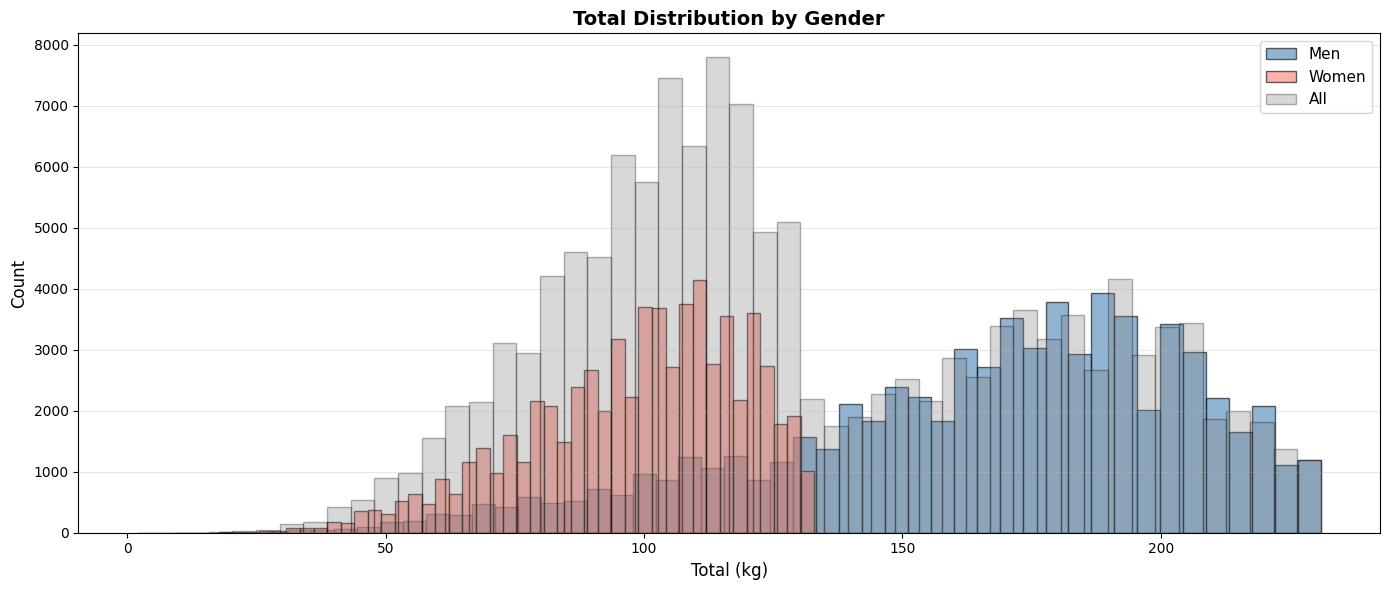

In [24]:
# Separate by gender
men_total_low = segment_low[segment_low['Gender'] == 'Men']['Total']
women_total_low = segment_low[segment_low['Gender'] == 'Women']['Total']
all_total_low = segment_low['Total']

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(men_total_low, bins=50, alpha=0.6, label='Men', color='steelblue', edgecolor='black')
plt.hist(women_total_low, bins=50, alpha=0.6, label='Women', color='salmon', edgecolor='black')
plt.hist(all_total_low, bins=50, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Total (kg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Total Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Attempt Success Rates

In [25]:
print("----------------------------------------------------------------------")
print("Missed Lift Rates By Attempt - Statistics:")

cols = ["Sn#1", "Sn#2", "Sn#3", "CJ#1", "CJ#2", "CJ#3"]
nan_rates_low = segment_low[cols].isna().mean() * 100
nan_rates_low = nan_rates_low.round(1).astype(str) + '%'
print(nan_rates_low)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

sn_nan_rate_low = segment_low[sn_cols].isna().sum().sum() / segment_low[sn_cols].size * 100
cj_nan_rate_low = segment_low[cj_cols].isna().sum().sum() / segment_low[cj_cols].size * 100

sn_nan_rate_low = f"{sn_nan_rate_low:.1f}%"
cj_nan_rate_low = f"{cj_nan_rate_low:.1f}%"

print("Snatch Miss Rate:", sn_nan_rate_low)
print("Clean & Jerk Miss Rate:", cj_nan_rate_low)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall By Gender - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

for gender, df_gender in segment_low.groupby("Gender"):
    sn_miss_rate_low = (
        df_gender[sn_cols].isna().sum().sum() / df_gender[sn_cols].size * 100
    )
    cj_miss_rate_low = (
        df_gender[cj_cols].isna().sum().sum() / df_gender[cj_cols].size * 100
    )

    print(f"Gender: {gender}")
    print(f"  Snatch Miss Rate:        {sn_miss_rate_low:.1f}%")
    print(f"  Clean & Jerk Miss Rate:  {cj_miss_rate_low:.1f}%")
    print()


----------------------------------------------------------------------
Missed Lift Rates By Attempt - Statistics:
Sn#1    12.8%
Sn#2    24.0%
Sn#3    40.1%
CJ#1     9.3%
CJ#2    22.2%
CJ#3    40.3%
dtype: object
----------------------------------------------------------------------
Missed Lift Rates Overall - Statistics:
Snatch Miss Rate: 25.6%
Clean & Jerk Miss Rate: 23.9%
----------------------------------------------------------------------
Missed Lift Rates Overall By Gender - Statistics:
Gender: Men
  Snatch Miss Rate:        25.5%
  Clean & Jerk Miss Rate:  24.5%

Gender: Women
  Snatch Miss Rate:        25.8%
  Clean & Jerk Miss Rate:  23.3%



#### Feature Correlations

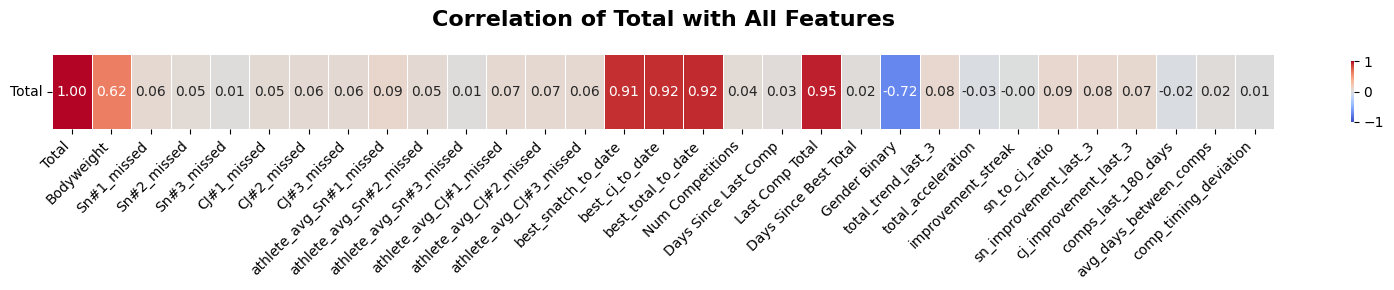

In [26]:
columns = ['Total', 'Bodyweight', 
           'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
           'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 
           'athlete_avg_Sn#1_missed', 'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
           'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed','athlete_avg_CJ#3_missed', 
           'best_snatch_to_date', 'best_cj_to_date',
           'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
           'Last Comp Total', 'Days Since Best Total',
           'Gender Binary', 'total_trend_last_3', 'total_acceleration',
           'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
           'cj_improvement_last_3', 'comps_last_180_days',
           'avg_days_between_comps', 'comp_timing_deviation']

# Calculate correlation matrix
corr_matrix = segment_low[columns].corr()

# Get only the first row (Total's correlation with everything)
total_corr = corr_matrix.iloc[0:1, :]  # Keep as DataFrame for heatmap

# Create figure
plt.figure(figsize=(16, 3))

# Create heatmap
sns.heatmap(total_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation of Total with All Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 50th-85th Percentile

#### Distribution of Totals

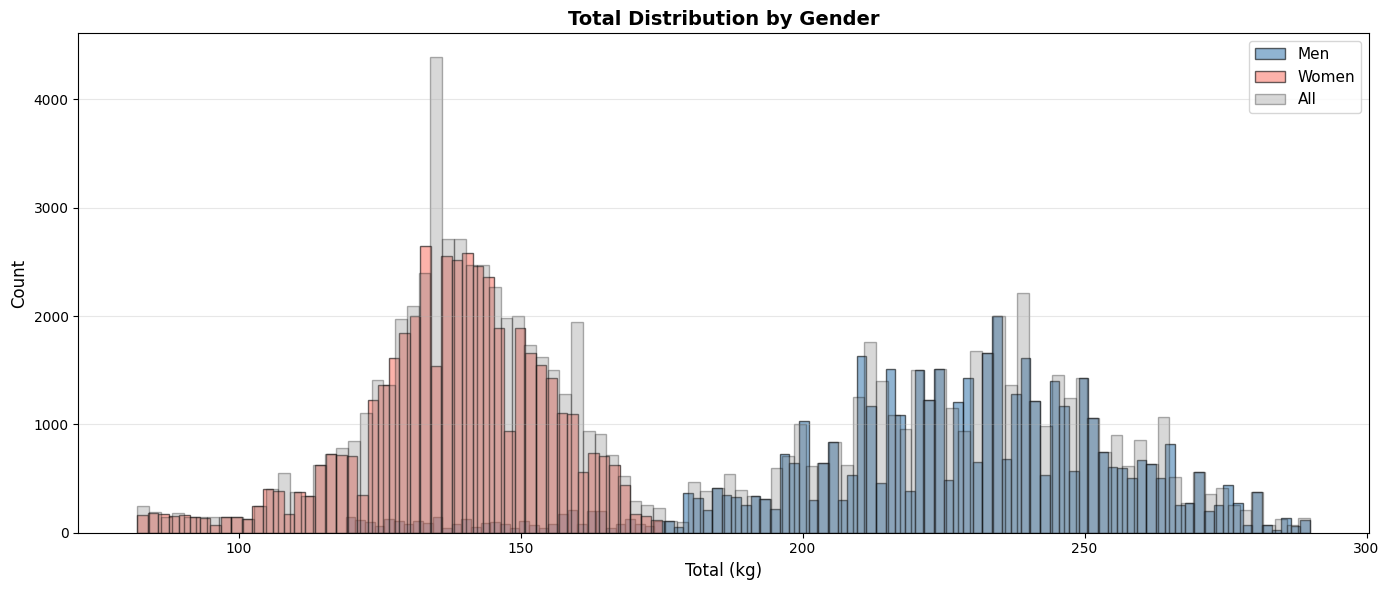

In [27]:
# Separate by gender
men_total_mid = segment_mid[segment_mid['Gender'] == 'Men']['Total']
women_total_mid = segment_mid[segment_mid['Gender'] == 'Women']['Total']
all_total_mid = segment_mid['Total']

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(men_total_mid, bins=100, alpha=0.6, label='Men', color='steelblue', edgecolor='black')
plt.hist(women_total_mid, bins=50, alpha=0.6, label='Women', color='salmon', edgecolor='black')
plt.hist(all_total_mid, bins=100, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Total (kg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Total Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Attempt Success Rates

In [28]:
print("----------------------------------------------------------------------")
print("Missed Lift Rates By Attempt - Statistics:")

cols = ["Sn#1", "Sn#2", "Sn#3", "CJ#1", "CJ#2", "CJ#3"]
nan_rates_mid = segment_mid[cols].isna().mean() * 100
nan_rates_mid = nan_rates_mid.round(1).astype(str) + '%'
print(nan_rates_mid)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

sn_nan_rate_mid = segment_mid[sn_cols].isna().sum().sum() / segment_mid[sn_cols].size * 100
cj_nan_rate_mid = segment_mid[cj_cols].isna().sum().sum() / segment_mid[cj_cols].size * 100

sn_nan_rate_mid = f"{sn_nan_rate_mid:.1f}%"
cj_nan_rate_mid = f"{cj_nan_rate_mid:.1f}%"

print("Snatch Miss Rate:", sn_nan_rate_mid)
print("Clean & Jerk Miss Rate:", cj_nan_rate_mid)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall By Gender - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

for gender, df_gender in segment_mid.groupby("Gender"):
    sn_miss_rate_mid = (
        df_gender[sn_cols].isna().sum().sum() / df_gender[sn_cols].size * 100
    )
    cj_miss_rate_mid = (
        df_gender[cj_cols].isna().sum().sum() / df_gender[cj_cols].size * 100
    )

    print(f"Gender: {gender}")
    print(f"  Snatch Miss Rate:        {sn_miss_rate_mid:.1f}%")
    print(f"  Clean & Jerk Miss Rate:  {cj_miss_rate_mid:.1f}%")
    print()

----------------------------------------------------------------------
Missed Lift Rates By Attempt - Statistics:
Sn#1    15.6%
Sn#2    26.6%
Sn#3    42.0%
CJ#1    10.8%
CJ#2    26.3%
CJ#3    46.8%
dtype: object
----------------------------------------------------------------------
Missed Lift Rates Overall - Statistics:
Snatch Miss Rate: 28.0%
Clean & Jerk Miss Rate: 28.0%
----------------------------------------------------------------------
Missed Lift Rates Overall By Gender - Statistics:
Gender: Men
  Snatch Miss Rate:        27.9%
  Clean & Jerk Miss Rate:  28.5%

Gender: Women
  Snatch Miss Rate:        28.1%
  Clean & Jerk Miss Rate:  27.4%



#### Feature Correlations

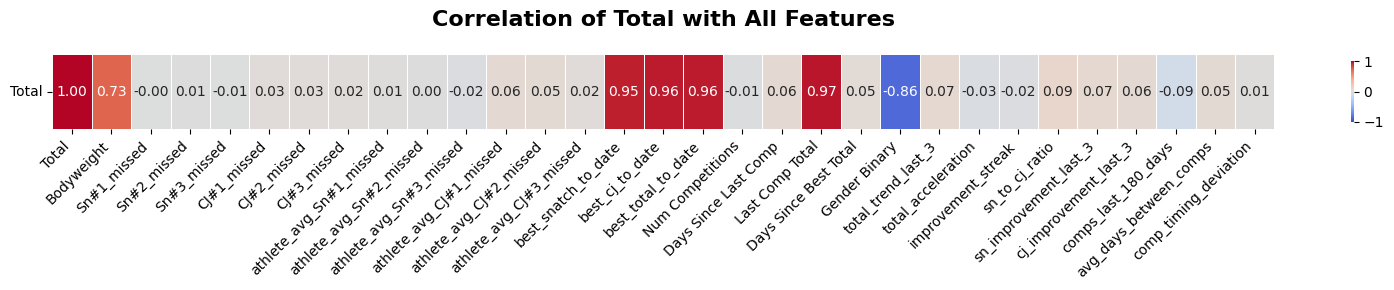

In [29]:
columns = ['Total', 'Bodyweight', 
           'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
           'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 
           'athlete_avg_Sn#1_missed', 'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
           'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed','athlete_avg_CJ#3_missed', 
           'best_snatch_to_date', 'best_cj_to_date',
           'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
           'Last Comp Total', 'Days Since Best Total',
           'Gender Binary', 'total_trend_last_3', 'total_acceleration',
           'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
           'cj_improvement_last_3', 'comps_last_180_days',
           'avg_days_between_comps', 'comp_timing_deviation']

# Calculate correlation matrix
corr_matrix = segment_mid[columns].corr()

# Get only the first row (Total's correlation with everything)
total_corr = corr_matrix.iloc[0:1, :]  # Keep as DataFrame for heatmap

# Create figure
plt.figure(figsize=(16, 3))

# Create heatmap
sns.heatmap(total_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation of Total with All Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 85th-100th Percentile

#### Distribution of Totals

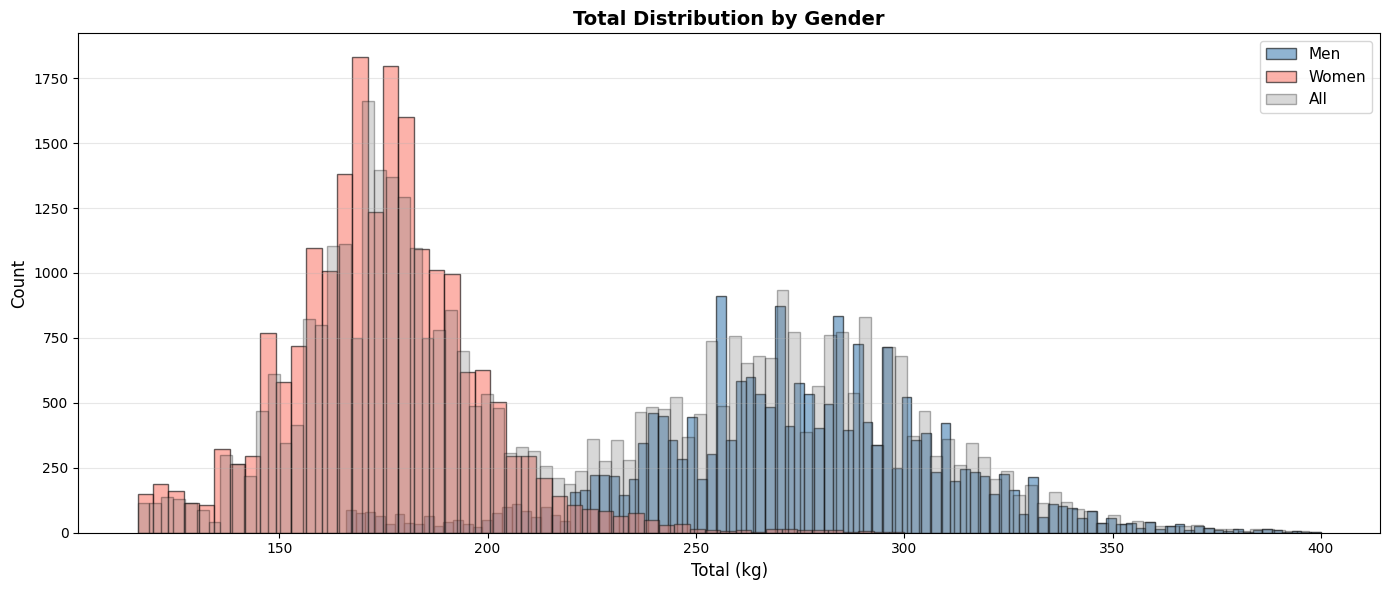

In [30]:
# Separate by gender
men_total_high = segment_high[segment_high['Gender'] == 'Men']['Total']
women_total_high = segment_high[segment_high['Gender'] == 'Women']['Total']
all_total_high = segment_high['Total']

# Create the distribution plot
plt.figure(figsize=(14, 6))

plt.hist(men_total_high, bins=100, alpha=0.6, label='Men', color='steelblue', edgecolor='black')
plt.hist(women_total_high, bins=50, alpha=0.6, label='Women', color='salmon', edgecolor='black')
plt.hist(all_total_high, bins=100, alpha=0.3, label='All', color='gray', edgecolor='black')

plt.xlabel('Total (kg)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Total Distribution by Gender', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Attempt Miss Rates

In [31]:
print("----------------------------------------------------------------------")
print("Missed Lift Rates By Attempt - Statistics:")

cols = ["Sn#1", "Sn#2", "Sn#3", "CJ#1", "CJ#2", "CJ#3"]
nan_rates_high = segment_high[cols].isna().mean() * 100
nan_rates_high = nan_rates_high.round(1).astype(str) + '%'
print(nan_rates_high)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

sn_nan_rate_high = segment_high[sn_cols].isna().sum().sum() / segment_high[sn_cols].size * 100
cj_nan_rate_high = segment_high[cj_cols].isna().sum().sum() / segment_high[cj_cols].size * 100

sn_nan_rate_high = f"{sn_nan_rate_high:.1f}%"
cj_nan_rate_high = f"{cj_nan_rate_high:.1f}%"

print("Snatch Miss Rate:", sn_nan_rate_high)
print("Clean & Jerk Miss Rate:", cj_nan_rate_high)

print("----------------------------------------------------------------------")
print("Missed Lift Rates Overall By Gender - Statistics:")
sn_cols = ["Sn#1", "Sn#2", "Sn#3"]
cj_cols = ["CJ#1", "CJ#2", "CJ#3"]

for gender, df_gender in segment_high.groupby("Gender"):
    sn_miss_rate_high = (
        df_gender[sn_cols].isna().sum().sum() / df_gender[sn_cols].size * 100
    )
    cj_miss_rate_high = (
        df_gender[cj_cols].isna().sum().sum() / df_gender[cj_cols].size * 100
    )

    print(f"Gender: {gender}")
    print(f"  Snatch Miss Rate:        {sn_miss_rate_high:.1f}%")
    print(f"  Clean & Jerk Miss Rate:  {cj_miss_rate_high:.1f}%")
    print()

----------------------------------------------------------------------
Missed Lift Rates By Attempt - Statistics:
Sn#1    16.9%
Sn#2    28.4%
Sn#3    43.3%
CJ#1    13.3%
CJ#2    30.7%
CJ#3    52.5%
dtype: object
----------------------------------------------------------------------
Missed Lift Rates Overall - Statistics:
Snatch Miss Rate: 29.5%
Clean & Jerk Miss Rate: 32.2%
----------------------------------------------------------------------
Missed Lift Rates Overall By Gender - Statistics:
Gender: Men
  Snatch Miss Rate:        29.5%
  Clean & Jerk Miss Rate:  32.8%

Gender: Women
  Snatch Miss Rate:        29.5%
  Clean & Jerk Miss Rate:  31.5%



#### Feature Correlations

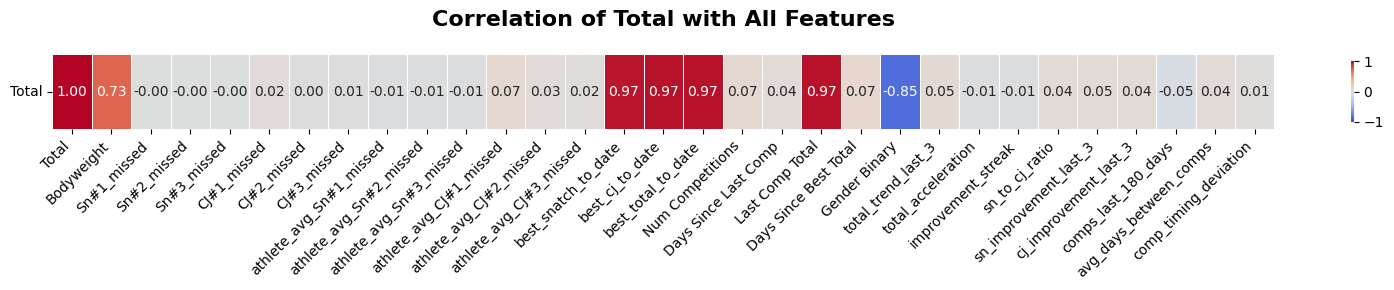

In [32]:
columns = ['Total', 'Bodyweight', 
           'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
           'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 
           'athlete_avg_Sn#1_missed', 'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
           'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed','athlete_avg_CJ#3_missed', 
           'best_snatch_to_date', 'best_cj_to_date',
           'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
           'Last Comp Total', 'Days Since Best Total',
           'Gender Binary', 'total_trend_last_3', 'total_acceleration',
           'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
           'cj_improvement_last_3', 'comps_last_180_days',
           'avg_days_between_comps', 'comp_timing_deviation']

# Calculate correlation matrix
corr_matrix = segment_high[columns].corr()

# Get only the first row (Total's correlation with everything)
total_corr = corr_matrix.iloc[0:1, :]  # Keep as DataFrame for heatmap

# Create figure
plt.figure(figsize=(16, 3))

# Create heatmap
sns.heatmap(total_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation of Total with All Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Models

In [33]:
# Load dependencies
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#from tensorflow import keras
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler

In [34]:
# Prep data
# Split by date
train = df_cleaned[df_cleaned['Date'] < '2024-01-01']
test = df_cleaned[df_cleaned['Date'] >= '2024-01-01']

# Features and target
feature_cols = ['Bodyweight', 
           'Sn#1_missed', 'Sn#2_missed', 'Sn#3_missed',
           'CJ#1_missed', 'CJ#2_missed', 'CJ#3_missed', 
           'athlete_avg_Sn#1_missed', 'athlete_avg_Sn#2_missed', 'athlete_avg_Sn#3_missed',
           'athlete_avg_CJ#1_missed', 'athlete_avg_CJ#2_missed','athlete_avg_CJ#3_missed', 
           'best_snatch_to_date', 'best_cj_to_date',
           'best_total_to_date', 'Num Competitions', 'Days Since Last Comp',
           'Last Comp Total', 'Days Since Best Total',
           'Gender Binary', 'total_trend_last_3', 'total_acceleration',
           'improvement_streak', 'sn_to_cj_ratio', 'sn_improvement_last_3',
           'cj_improvement_last_3', 'comps_last_180_days',
           'avg_days_between_comps', 'comp_timing_deviation'] 
                
X_train = train[feature_cols]
y_train = train['Total']
X_test = test[feature_cols]
y_test = test['Total']

# Handle NaNs
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [35]:
# Model 1: Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [36]:
# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [37]:
# Model 3: XGBoost
xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [47]:
# Model 4: Simple Neural Net
# Scale features
'''
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(1)
])

# Better optimizer with learning rate schedule
optimizer = keras.optimizers.Adam(learning_rate=0.001)
nn.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# Callbacks for better training
callbacks = [
    # Stop early if validation loss stops improving
    EarlyStopping(
        monitor='val_mae',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when plateauing
    ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Save best model
    ModelCheckpoint(
        'best_nn_model.keras',
        monitor='val_mae',
        save_best_only=True,
        verbose=0
    )
]

# Train with callbacks
history = nn.fit(
    X_train_scaled, y_train,
    epochs=100,  # More epochs but will stop early
    batch_size=64,  # Larger batch size for stability
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Predict
nn_pred = nn.predict(X_test_scaled).flatten()
'''

"\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\nnn = keras.Sequential([\n    keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),\n    keras.layers.BatchNormalization(),\n    keras.layers.Dropout(0.3),\n    \n    keras.layers.Dense(64, activation='relu'),\n    keras.layers.BatchNormalization(),\n    keras.layers.Dropout(0.3),\n    \n    keras.layers.Dense(32, activation='relu'),\n    keras.layers.BatchNormalization(),\n    keras.layers.Dropout(0.2),\n    \n    keras.layers.Dense(16, activation='relu'),\n    keras.layers.Dropout(0.2),\n    \n    keras.layers.Dense(1)\n])\n\n# Better optimizer with learning rate schedule\noptimizer = keras.optimizers.Adam(learning_rate=0.001)\nnn.compile(optimizer=optimizer, loss='mse', metrics=['mae'])\n\n# Callbacks for better training\ncallbacks = [\n    # Stop early if validation loss stops improving\n    EarlyStopping(\n        monitor='val_mae',\n     

### Model Comparison

In [46]:
models = {
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    #'Neural Net': nn_pred
}

print("Model Performance Comparison:")
print("-" * 64)
for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name:20} | MAE: {mae:.2f}kg | RMSE: {rmse:.2f}kg | R²: {r2:.3f}")

Model Performance Comparison:
----------------------------------------------------------------
Linear Regression    | MAE: 16.58kg | RMSE: 24.05kg | R²: 0.853
Random Forest        | MAE: 10.60kg | RMSE: 17.91kg | R²: 0.919
XGBoost              | MAE: 10.20kg | RMSE: 17.59kg | R²: 0.922


### Tuning Hyperparameters for XGBoost

In [39]:
# Now, tune Hyperparameters for XGB
xgb_param_grid = {
    'max_depth': [5, 6, 7, 8, 9],
    'learning_rate': [0.02, 0.03, 0.04, 0.05, 0.07],
    'n_estimators': [300, 350, 400, 450, 500],
    'subsample': [1.0]
}

xgb_tuned = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    n_iter=10,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=2
)

xgb_tuned.fit(X_train, y_train)
print(f"\nXGBoost Best params: {xgb_tuned.best_params_}")
print(f"XGBoost Best MAE: {-xgb_tuned.best_score_:.2f}kg")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END learning_rate=0.02, max_depth=8, n_estimators=450, subsample=1.0; total time=   7.1s
[CV] END learning_rate=0.02, max_depth=8, n_estimators=450, subsample=1.0; total time=   7.8s
[CV] END learning_rate=0.02, max_depth=8, n_estimators=450, subsample=1.0; total time=  11.0s
[CV] END learning_rate=0.02, max_depth=8, n_estimators=450, subsample=1.0; total time=  11.1s
[CV] END learning_rate=0.02, max_depth=8, n_estimators=450, subsample=1.0; total time=  11.0s
[CV] END learning_rate=0.03, max_depth=8, n_estimators=400, subsample=1.0; total time=   9.2s
[CV] END learning_rate=0.03, max_depth=8, n_estimators=400, subsample=1.0; total time=   9.2s
[CV] END learning_rate=0.03, max_depth=8, n_estimators=400, subsample=1.0; total time=   9.7s
[CV] END learning_rate=0.03, max_depth=8, n_estimators=400, subsample=1.0; total time=   9.6s
[CV] END learning_rate=0.03, max_depth=8, n_estimators=400, subsample=1.0; total time=   9.7s

In [41]:
## Compare
xgb_tuned_pred = xgb_tuned.predict(X_test)

print("\n" + "="*60)
print("Test Set Comparison:")
print(f"Original XGB        | MAE: {mean_absolute_error(y_test, xgb_pred):.2f}kg")
print(f"Tuned XGBoost       | MAE: {mean_absolute_error(y_test, xgb_tuned_pred):.2f}kg")


tuned_xgb_mae = mean_absolute_error(y_test, xgb_tuned_pred)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))
tuned_xgb_r2 = r2_score(y_test, xgb_tuned_pred)

print(f"Tuned XGBoost       | MAE: {tuned_xgb_mae:.2f}kg | RMSE: {tuned_xgb_rmse:.2f}kg | R²: {tuned_xgb_r2:.3f}")



Test Set Comparison:
Original XGB        | MAE: 10.20kg
Tuned XGBoost       | MAE: 10.04kg
Tuned XGBoost       | MAE: 10.04kg | RMSE: 17.47kg | R²: 0.923


## Segment Aware Analysis

### Percentiles

#### Evaluate Error

In [44]:
bottom_50 = test[test['performance_percentile'] < 0.5]
mid_50_85 = test[
    (test['performance_percentile'] >= 0.5) &
    (test['performance_percentile'] < 0.85)
]
top_15 = test[test['performance_percentile'] >= 0.85]

def eval_segment(segment, model):
    X = segment[feature_cols]
    # Handle NaNs
    X = X.fillna(0)
    y_true = segment['Total']
    y_pred = model.predict(X)
    
    return mean_absolute_error(y_true, y_pred)

new_models = {
    'Linear Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_tuned,
    #'Neural Net': nn
}

print("Model Performance Comparison (Segment Aware):")
for name, model in new_models.items():
    mae_bottom = eval_segment(bottom_50, model)
    mae_mid = eval_segment(mid_50_85, model)
    mae_top = eval_segment(top_15, model)
    print("-" * 64)
    print(f"Model: {name}")
    print(f"0th-50th   Percentile MAE: {mae_bottom:.2f}kg")
    print(f"50th-85th  Percentile MAE: {mae_mid:.2f}kg")
    print(f"85th-100th Percentile MAE: {mae_top:.2f}kg")


Model Performance Comparison (Segment Aware):
----------------------------------------------------------------
Model: Linear Regression
0th-50th   Percentile MAE: 63.28kg
50th-85th  Percentile MAE: 49.18kg
85th-100th Percentile MAE: 15.49kg
----------------------------------------------------------------
Model: Random Forest
0th-50th   Percentile MAE: 54.07kg
50th-85th  Percentile MAE: 38.55kg
85th-100th Percentile MAE: 10.33kg
----------------------------------------------------------------
Model: XGBoost
0th-50th   Percentile MAE: 52.17kg
50th-85th  Percentile MAE: 36.82kg
85th-100th Percentile MAE: 9.77kg


<Figure size 800x600 with 0 Axes>

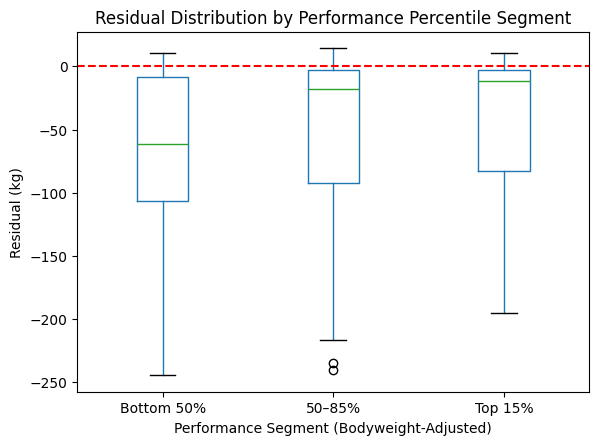

In [45]:
eval_df = test.copy()
eval_df["Residual"] = eval_df["Total"] - xgb_tuned.predict(eval_df[feature_cols])

eval_df["Segment"] = pd.cut(
    eval_df["performance_percentile"],
    bins=[0, 0.5, 0.85, 1.0],
    labels=["Bottom 50%", "50–85%", "Top 15%"]
)

plt.figure(figsize=(8,6))
eval_df.boxplot(
    column="Residual",
    by="Segment",
    grid=False
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Distribution by Performance Percentile Segment")
plt.suptitle("")
plt.xlabel("Performance Segment (Bodyweight-Adjusted)")
plt.ylabel("Residual (kg)")
plt.show()


#### MAE Discrepancy, Neural Network Issue

Segment-aware evaluation exposes a significant discrepancy among MAE's for each percentile; getting smaller as the percentile increases. This is heteroskedasticity, and it's clear how it has occured. First, lower percentiles have much higher variability implicitly, as they are likely to vary their totals wildly, either increasing quickly or missing lifts randomly. Along with that, our feature engineering is specifically biased towards athletes that have multiple competitions. This means that our top 15th percentile category will have much more precise information on their % missed lifts, trajectories, etc. and are more stable with changes in total. 

The neural network fails upon segmented evaluation, and upon further exploration, it makes sense why. Neural networks are naturally unconstrained -- their outputs are not naturally bounded to what we'd expect total's range to be, so it's possible to get the error we did. Since our code didn't change from our overall model (with a relatively normal MAE result) to our segmented models, the natural cause would be that errors are masked by the full model, and exposed in the segmented models. This is because MAE is mean and not median, allowing a few massive outliers to go unnoticed. 

#### Do we change any model? Why?

Out of the four models tested, only the Neural Network could do with some individualized changes. The Linear Regression, RF and XGB all have reasonable guesses, with segments getting more accurate as they increase, something that makes sense as lifters gain stability, and also have more feature engineered columns geared towards them.
While I could change the Neural Network, I elected to leave it. I could bound results, either to general bounds (0-400kg), or more specifically if we have data like their last total (probably would be within 100kg of said last total). I could also create more generalized feature engineering, a better loss function, or dive into the model's heteroskedasticity. But the reason I won't is that this data is tabular and structured, something I assumed would work better for models like Random Forest and XGBoost. Along with that, the tree based models

## Key Findings

### Dataset
- Roughly 300,000 total competition entries from 2012-2025
- Peak competition year was 2019, with 27,770 total competition entries

### Strongest Predictors of Total
- Last comp total to date was the strongest predictor of current total (Correlation: 0.98)
- Best comp total to date was the second strongest predictor (Correlation: 0.97) along with best snatch to date and best clean and jerk to date (Correlations being 0.96)
- Gender binary and bodyweight showed moderate correlations (0.58, 0.62 respectively)

### Model Performance
- XGB outperformed all models with a test MAE of 10.02kg.
- The neural network and random forest both performed comparably with XGB (MAE:10.82kg, 10.61kg), but the neural network broke down in segmented evaluation, exposing unbounded predictions
- Linear regression as a baseline model achieved an MAE of 16.58kg, which highlights that the majority of our predictive signals are linear.

### Segmented Evaluation
- All models showed heteroskedasticity across performance tiers
- Bottom 50th percentile had an MAE of 52.36kg, while the top 15th percentile had an MAE of 9.76kg, roughly 5.5 times more accurate predictions for elite athletes
- Elite athletes have a richer history (which increases the accuracy of engineered features) and are more likely to gradually improve or worsen.

### Miss Rates
- Overall miss rates: Snatch - 26.8%, Clean & Jerk - 26.2%
- First attempt misses for Clean & Jerk were rarest (10.3%), while Clean & Jerk third attempts were the most frequent (43.8%).
- Full order: (CJ1, SN1, CJ2, SN2, SN3, CJ3)
- This is consistent with competitive attempt selection strategies
- Top 15th percentile athletes miss rates: Snatch - 29.5%, Clean & Jerk - 32.2%
- Bottom 50th percentile athletes miss rates: Snatch - 25.6%, Clean & Jerk - 23.9%

## Error Analysis

### Overall Residual Distribution (Tuned XGB)
- As shown in our graph under "Segment Aware Analysis", the model's error shrinks significantly at higher performance percentiles, confirming the heteroskedasticity identified in segmented evaluation
- Along with that, lower percentile athletes show a wider residual spread, consistent with sparser feature histories.

## Limitations and Bias

- Like names are included togther
- Not able to model on age of lifter
- Not able to see athlete training, injury, etc.
- Some weight classes are "better" in comparison to top weightlifters of the world, some are not
- Biased information towards athletes who have lifted for longer
- Removed "bomb outs"

## Future Work

- Increase the number of segments (especially higher percentiles)
- Scrape by athlete instead of by meet, has more individual information, but only slightly (only has age, region as other features)
- Focus on higher percentiles with modeling
- Model when an athlete's next meet will be, based on their averages
- Create interactive visuals for people to use this information practically
- Include "Bomb outs", could have models include risk of failure and work into model, may be difficult but could be an enjoyable challenge